# swmmer: run a model, plot it, analyze it

An end-to-end tour of `swmmer` on the official **EPA SWMM Example 1** (a small urban
catchment with 8 subcatchments draining a 13-node pipe network to one
outfall). We:

1. draw the network straight from the `.inp`,
2. run the bundled SWMM engine,
3. read the binary `.out` results as NumPy arrays,
4. plot hyetograph/hydrographs and a pipe long-profile,
5. do a bit of analysis and overlay the results back on the map.

Plotting uses `swmmer.plot` (matplotlib only, `pip install swmmer[plot]`).

In [1]:
from __future__ import annotations

import tempfile
from pathlib import Path

import matplotlib.pyplot as plt

import swmmer
from swmmer import LinkAttr, NodeAttr, SubcatchAttr, SWMMResults, SystemAttr, run_swmm

INP = Path("data/example1.inp")
swmmer.__version__

'0.1.2.dev1+ga26cf370d.d20260710'

## 1. The network, before running anything

`swmmer.plot.read_inp` parses the geometry (coordinates, conduits, polygons)
and `plot_network` draws subcatchments, pipes and nodes.

8 subcatchments, 14 nodes, 13 links


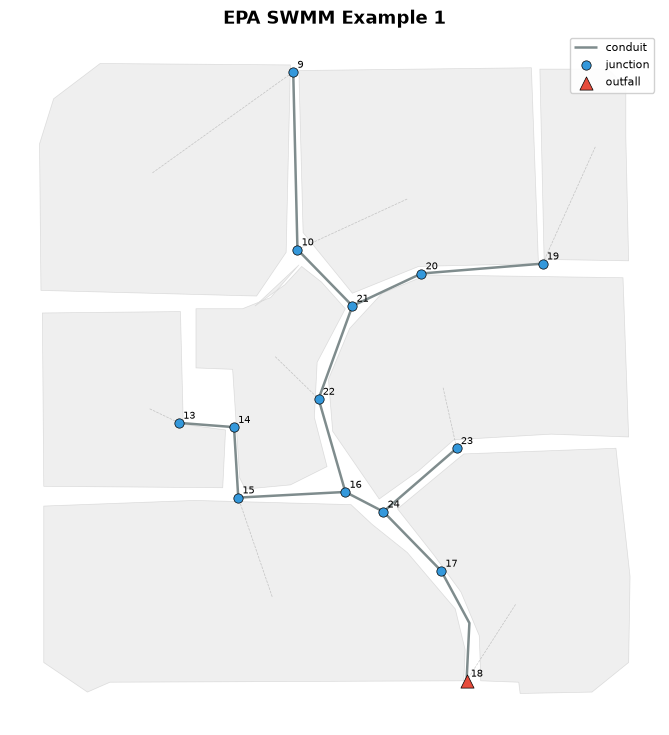

In [2]:
data = swmmer.plot.read_inp(INP)
print(f"{len(data.subcatchments)} subcatchments, {len(data.nodes)} nodes, {len(data.links)} links")

fig, _ = swmmer.plot.plot_network(data, labels=True, title="EPA SWMM Example 1")

## 2. Run the model

`run_swmm` invokes the bundled `runswmm` engine and returns the report and
binary-output paths. We write outputs to a temp dir to keep the repo clean.

In [3]:
work = Path(tempfile.mkdtemp())
rpt, out = run_swmm(INP, rpt=work / "example1.rpt", out=work / "example1.out", progress_bar=True)
print("report:", rpt.name, "| output:", out.name)

  0%|          |

report: example1.rpt | output: example1.out


## 3. Read results

`SWMMResults` reads the `.out` via the EPA C library. Series come back as
NumPy arrays aligned to `times_hours`.

In [4]:
res = SWMMResults(out)
t = res.times_hours
print(f"{len(t)} report steps over {t[-1]:.1f} h")
print("nodes:", res.node_names[:5], "…")
print("links:", res.link_names[:5], "…")

36 report steps over 36.0 h
nodes: ['9', '10', '13', '14', '15'] …
links: ['1', '4', '5', '6', '7'] …


## 4a. System hyetograph + hydrograph

System-wide series (`SystemAttr`): rainfall on top (as a hyetograph), total
outfall discharge and total flooding below.

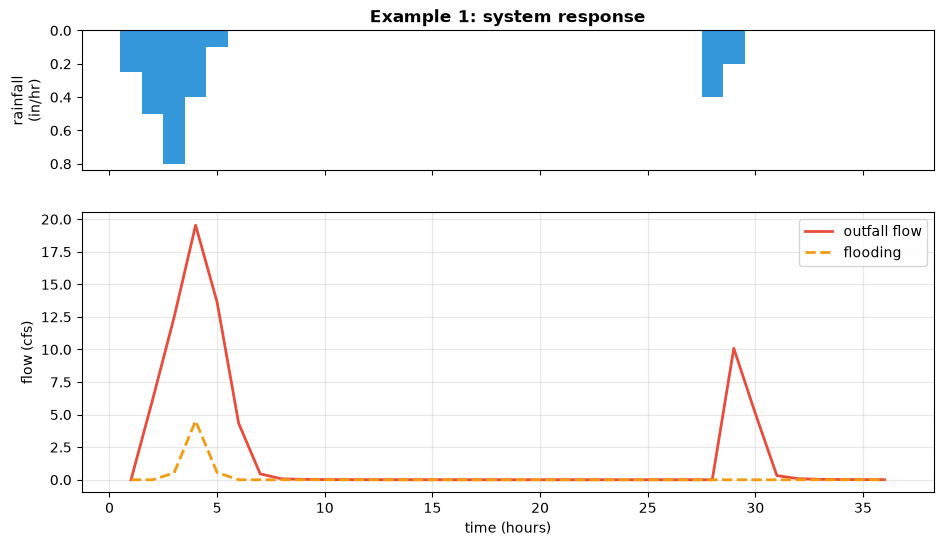

In [5]:
rain = res.system_series(SystemAttr.RAINFALL)
outflow = res.system_series(SystemAttr.OUTFALL_FLOW)
flooding = res.system_series(SystemAttr.FLOODING)

fig, (top, bot) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, height_ratios=[1, 2])
top.bar(t, rain, width=t[1] - t[0], color="#3498db")
top.invert_yaxis()
top.set_ylabel("rainfall\n(in/hr)")
top.set_title("Example 1: system response", fontweight="bold")
bot.plot(t, outflow, color="#e74c3c", lw=2, label="outfall flow")
bot.plot(t, flooding, color="#f39c12", lw=2, ls="--", label="flooding")
bot.set_xlabel("time (hours)")
bot.set_ylabel("flow (cfs)")
bot.legend()
bot.grid(visible=True, alpha=0.3)

## 4b. Per-element hydrographs

Any node/link/subcatchment series by name. Here: runoff from the largest
subcatchment and flow in the busiest conduit (picked by peak).

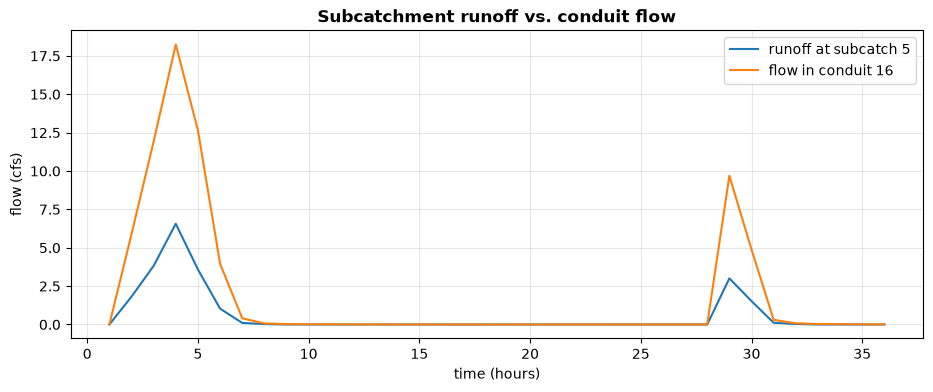

In [6]:
peak_flow = {name: res.link_series(name, LinkAttr.FLOW).max() for name in res.link_names}
busiest = max(peak_flow, key=peak_flow.get)
big_sub = max(
    res.subcatchment_names, key=lambda s: float(data.subcatchments.get(s, {}).get("area", 0.0))
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    t, res.subcatchment_series(big_sub, SubcatchAttr.RUNOFF), label=f"runoff at subcatch {big_sub}"
)
ax.plot(t, res.link_series(busiest, LinkAttr.FLOW), label=f"flow in conduit {busiest}")
ax.set_xlabel("time (hours)")
ax.set_ylabel("flow (cfs)")
ax.set_title("Subcatchment runoff vs. conduit flow", fontweight="bold")
ax.legend()
ax.grid(visible=True, alpha=0.3)

## 5. Longitudinal profile

`plot_profile` walks the pipe network downstream from a headwater to the
outfall and draws the invert / crown / ground long-section.

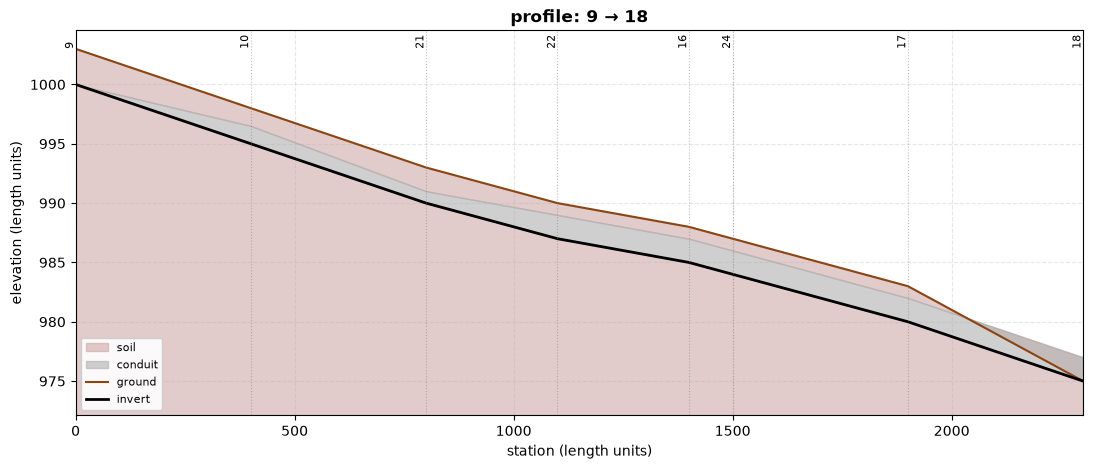

In [7]:
outfall = next(n for n, s in data.nodes.items() if s["node_type"] == "outfall")
downstream = {link["to_node"] for link in data.links.values()}
headwater = next(
    link["from_node"] for link in data.links.values() if link["from_node"] not in downstream
)

fig, _ = swmmer.plot.plot_profile(data, headwater, outfall)

## 6. Analysis

Peak flow per conduit, and total flooded volume per node. `to_pandas` gives a
tidy time-indexed DataFrame when pandas is installed (`swmmer[pandas]`).

In [8]:
dt_s = (t[1] - t[0]) * 3600.0
flood_vol = {n: res.node_series(n, NodeAttr.FLOODING).sum() * dt_s for n in res.node_names}
flooded = {n: v for n, v in flood_vol.items() if v > 0}

print(f"peak system outfall flow : {outflow.max():.2f} cfs")
print(f"busiest conduit          : {busiest} at {peak_flow[busiest]:.2f} cfs")
print(f"nodes that flood         : {sorted(flooded) or 'none'}")

df = res.to_pandas(LinkAttr.FLOW, element_type="link")
df.iloc[:, :5].describe().loc[["max", "mean"]]

peak system outfall flow : 19.54 cfs
busiest conduit          : 16 at 18.24 cfs
nodes that flood         : ['10']


,1,4,5,6,7
max,4.638623,0.778871,0.774489,4.631762,5.401015
mean,0.423905,0.059612,0.059531,0.677321,0.737442


## 7. Overlay results on the map

Colour the pipes by peak flow and the nodes by peak flooding, the same map
from step 1, now telling us *where* the system is stressed.

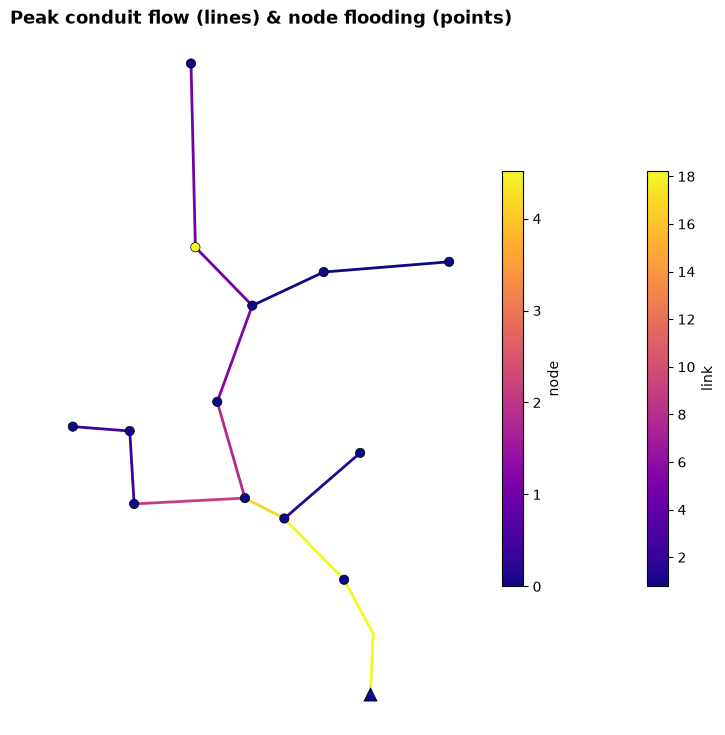

In [9]:
node_peak_flood = {n: res.node_series(n, NodeAttr.FLOODING).max() for n in res.node_names}
fig, _ = swmmer.plot.plot_network(
    data,
    link_values=peak_flow,
    node_values=node_peak_flood,
    show_subcatchments=False,
    cmap="plasma",
    title="Peak conduit flow (lines) & node flooding (points)",
)

That's the whole loop: build/read a model, run the engine, and turn the
binary output into plots and numbers, with NumPy as the only hard dependency.

In [10]:
res.close()